## 0. 서론

시작에 앞서서 저는 오늘 목표가 정확도 80.5퍼 달성 및 제출이 목적입니다
바뀔수도있긴함

**"My Spaceship Titanic 80.5%"** 이 아래글을 많이 참고하였습니다 AI의 도움도 받으면서 

레퍼런스 링크 :  
https://www.kaggle.com/code/adamml/my-spaceship-titanic-80-5

# 1. 모듈/라이브러리 import
## 아래와 같은 모듈과 라이브러리를 불러옵니다

In [66]:
# 기초 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import random as rnd
import re

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
%matplotlib inline

# 머신러닝 라이브러리
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier                         #만약에 라이브러리가 설치가 안되있다면 pip install 명령어로 다운을 받아야함 나중에 까먹을거니까 미리 적어둠


# 2. Spaceship Titanic 시작

## 2.1 데이터셋 불러오기

In [67]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

## 2.2 자료인 train_df, test_df 간단히 확인하기
정상적으로 불러와지는걸 확인

In [68]:
train_df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [69]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


#### info 명령어를 통하여 13개 칼럼 중 11개의 칼럼에서 미싱 데이터 확인을 하였으니 채워주겠습니다.
#### 아래 코드는 금액이나 탑승객 ID, 나이, 이름 등 수치 및 유니크한 데이터를 제외한 부분의 미싱 데이터를 확인하기위해 작성한 코드입니다.

In [70]:
print(train_df.columns.values)
print('========'*4)
print(train_df['HomePlanet'].value_counts())
print('========'*4)
print(train_df['Destination'].value_counts())
print('========'*4)
print(train_df['VIP'].value_counts())
print('========'*4)
print(train_df['Transported'].value_counts())
print('========'*4)
print(train_df['Cabin'].str[0].value_counts())
print('========'*4)
print(train_df['CryoSleep'].value_counts())
print('========'*4)
print(train_df['Age'].value_counts())

['PassengerId' 'HomePlanet' 'CryoSleep' 'Cabin' 'Destination' 'Age' 'VIP'
 'RoomService' 'FoodCourt' 'ShoppingMall' 'Spa' 'VRDeck' 'Name'
 'Transported']
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
VIP
False    8291
True      199
Name: count, dtype: int64
Transported
True     4378
False    4315
Name: count, dtype: int64
Cabin
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64
CryoSleep
False    5439
True     3037
Name: count, dtype: int64
Age
24.0    324
18.0    320
21.0    311
19.0    293
23.0    292
       ... 
75.0      4
79.0      3
78.0      3
76.0      2
77.0      2
Name: count, Length: 80, dtype: int64


#### 고향 향성 : 3 (Europa, Earth, Mars) ==> 카테고리
#### 극저온수면 : 2 (True/False) ==> 카테고리
#### 목적지 : 3 (TRAPPIST-1e, PSO J318.5-22, 55 Cancri e) ==> 카테고리
#### VIP 여부 : 2 (True/False) ==> 카테고리
#### 이송/전송됨 여부 : 2 (True/False) ==> 카테고리
#### 나이 : 0-80 ==> 연속적
#### 좌석 : 분리가 필요한부분 ==> 연속적인 데이터 및 카테고리 데이터로 분리
#### 룸서비스, 푸드코트, 쇼핑몰, 스파, VR덱 : 지출 연속적인것으로 유추
#### 탑승객 ID : 카테고리로 유추
#### 이름 : 이름 + 성 (고유 + 카테고리)
순서대로 정리하였습니다.

#### train 데이터는 모델 학습을 위해 사용되며, test 데이터는 학습된 모델의 성능을 평가하고 예측 결과를 제출하기 위해 사용된다.
#### test 데이터에는 정답 값이 포함되어 있지 않기 때문에 모델을 통해 예측을 수행해야 한다.
#### 그래서 train 데이터를 확인했으니 똑같은 코드를 사용하여 test해봅니다

In [71]:
test_df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [72]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


#### 고유값을 찾겠습니다

In [73]:
train_df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [74]:
test_df.nunique()

PassengerId     4277
HomePlanet         3
CryoSleep          2
Cabin           3265
Destination        3
Age               79
VIP                2
RoomService      842
FoodCourt        902
ShoppingMall     715
Spa              833
VRDeck           796
Name            4176
dtype: int64

## 2.3 missingno 라이브러리로 누락된 데이터를 찾기

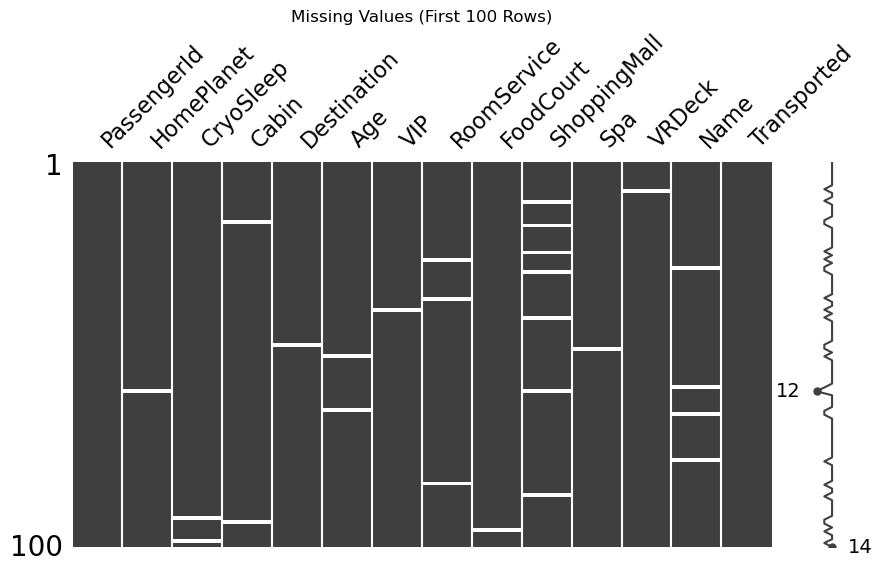

In [75]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(train_df.iloc[:100], figsize=(10,5))
plt.title('Missing Values (First 100 Rows)')
plt.show()

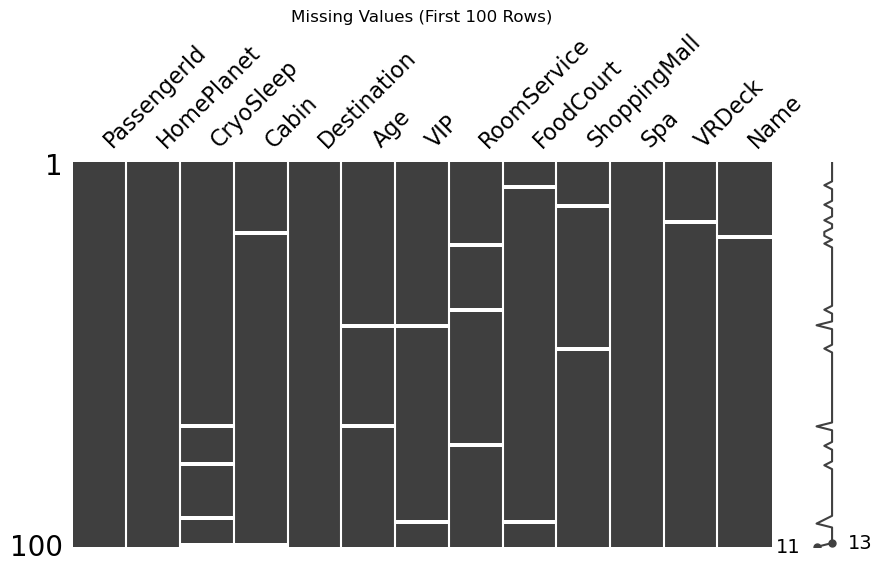

In [76]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(test_df.iloc[:100], figsize=(10,5))
plt.title('Missing Values (First 100 Rows)')
plt.show()

### missingno 라이브러리를 활용하여 결측치 분포를 시각화한 결과,
대부분의 데이터는 값이 존재하며 결측치는 일부 변수에서 소량 발생하는 것을 확인하였다.

또한 결측치는 특정 패턴 없이 데이터 전반에 걸쳐 고르게 분포되어 있어,
단순 대체 방식(중앙값, 최빈값 등)을 적용하는 것이 적절하다고 판단하였다.

## 2.4 EDA 시작

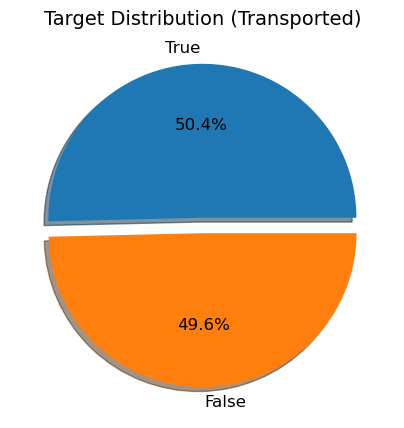

In [77]:
plt.figure(figsize=(5,5))

train_df['Transported'].value_counts().plot.pie(
    explode=[0.05, 0.05],
    autopct='%1.1f%%',
    shadow=True,
    textprops={'fontsize':12}
)

plt.title("Target Distribution (Transported)", fontsize=14)
plt.ylabel('')
plt.show()

#### 전송/이송 된 사람과 비율이 거의 균형을 이룬걸 확인

### 2.4.1 나이로 인한 전송률 

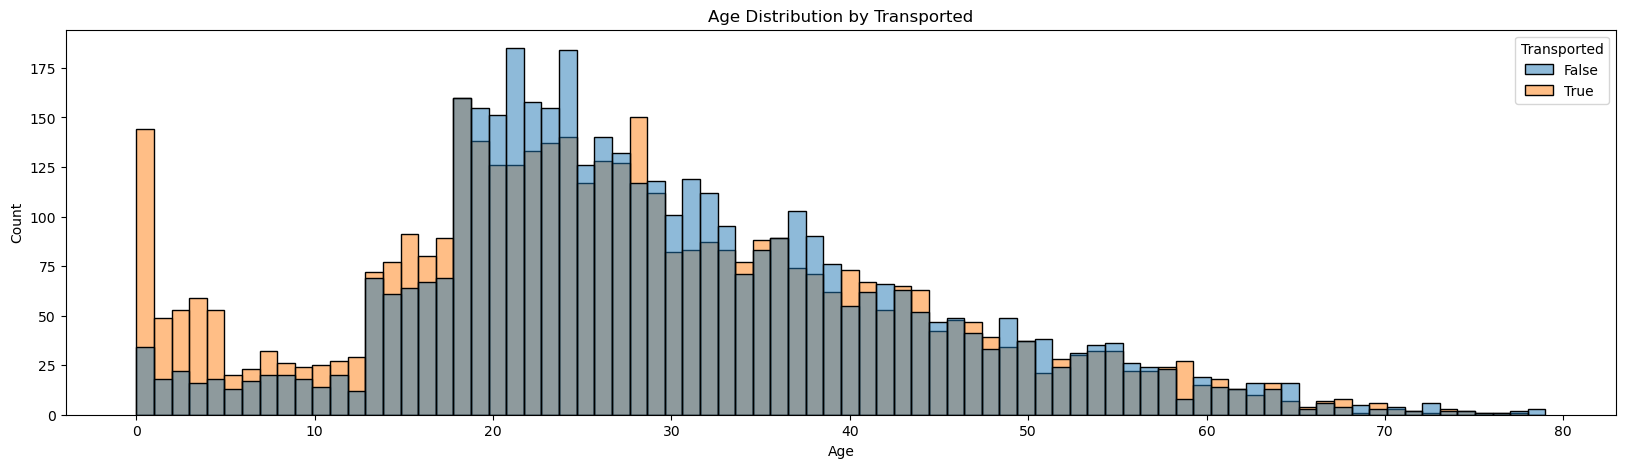

In [78]:
plt.figure(figsize=(20,5))

sns.histplot(data=train_df, x='Age', hue='Transported', bins=80)

plt.title('Age Distribution by Transported')
plt.show()

### 주석 : 전송/이송 비율 
 - 0~18세 : 이송됨 > 전송됨
 - 18~40세 : 이송됨 < 전송됨
 - 41세 이상부터는 그래프로 인한 확인이 어려움

### 2.4.2 지출로 알아보는 전송률

<function matplotlib.pyplot.show(close=None, block=None)>

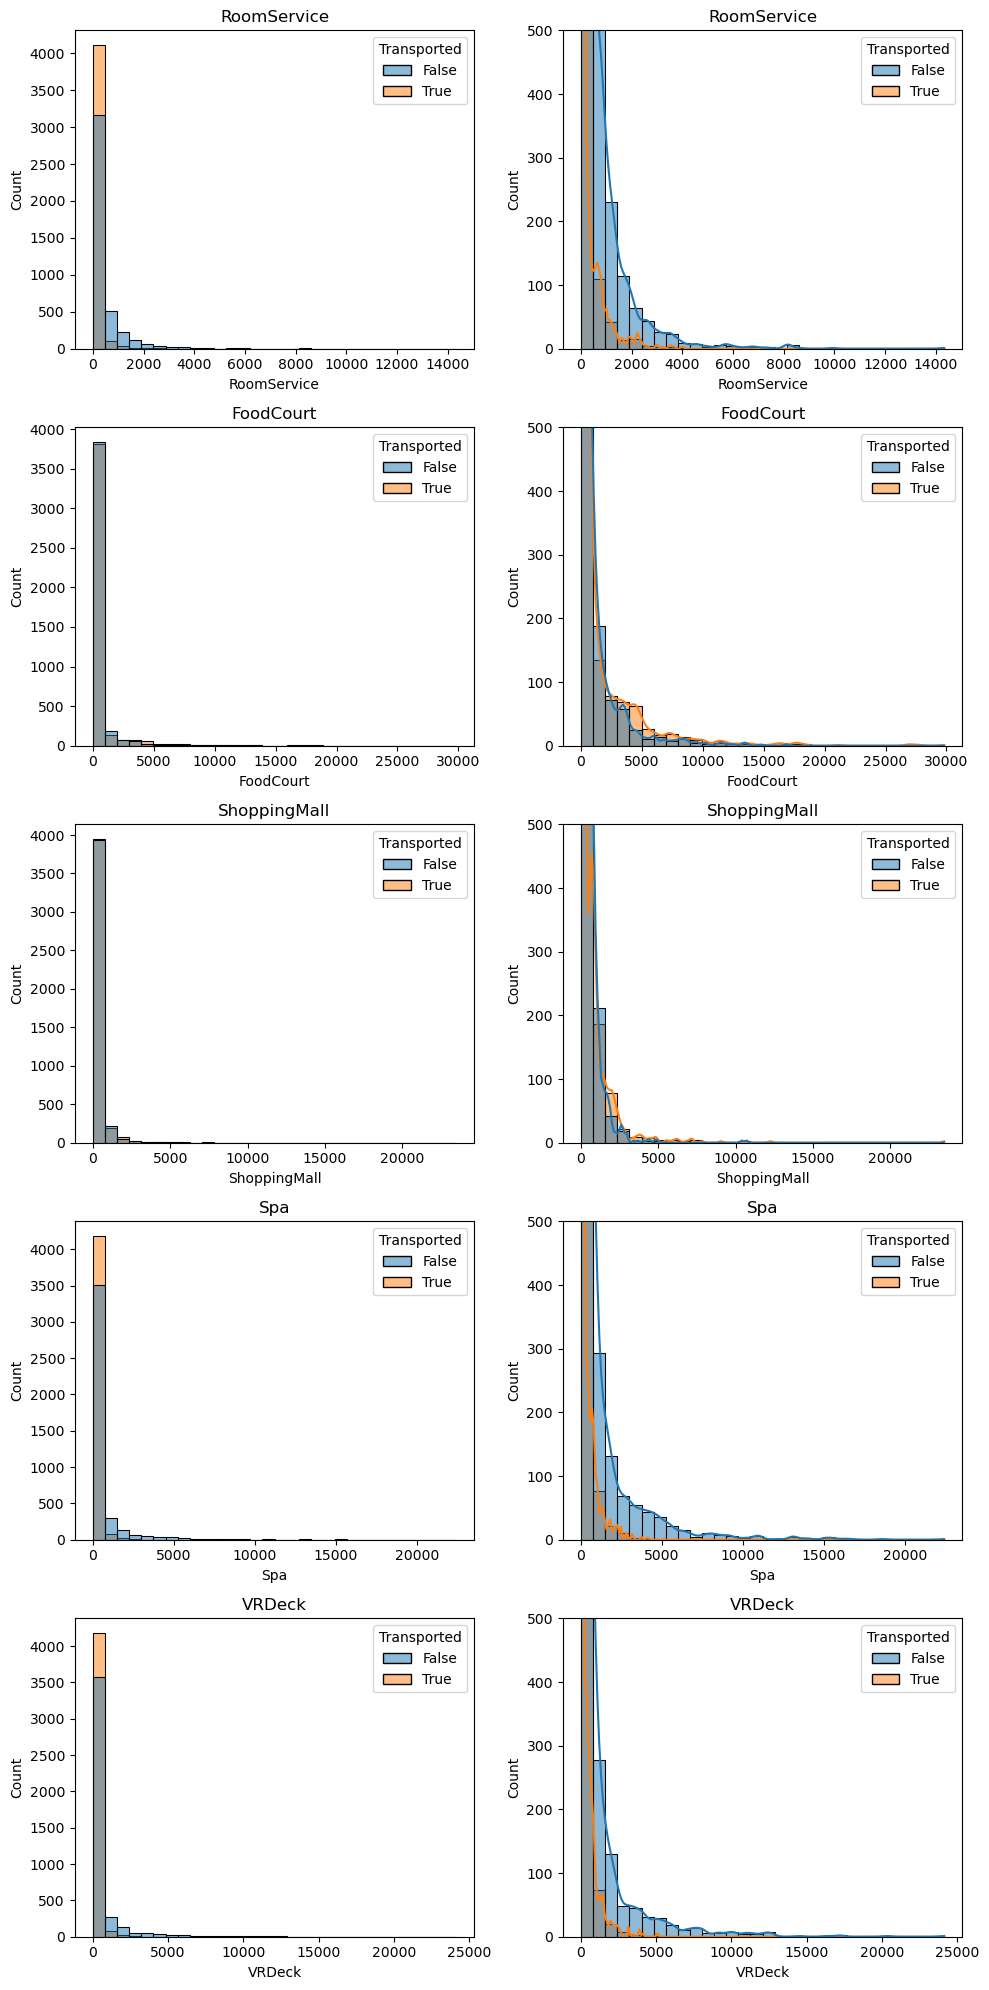

In [79]:
cona_feats=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] # 금액 관련 칼럼을 전부 끌어모아 함수를 재설정

fig=plt.figure(figsize=(10, 20)) # 그래프 크기 설정
for i, var_name in enumerate(cona_feats):
    ax=fig.add_subplot(5,2,2*i+1) 
    sns.histplot(data=train_df, x=var_name, axes=ax, bins=30, kde=False, hue='Transported')
    ax.set_title(var_name)
    
    ax=fig.add_subplot(5,2,2*i+2)
    sns.histplot(data=train_df, x=var_name, axes=ax, bins=30, kde=True, hue='Transported')
    plt.ylim([0,500])
    ax.set_title(var_name)
fig.tight_layout()
plt.show

#### 그래프를 통한 결과값
 - 많은 사람들이 5000원 이상을 사용하지 않았고 돈을 아끼는걸 알수있음
 - 돈을 아낄 수록, 더 많은 사람들이 전송/이송되었다(돈을 아낀 사람들이 더욱 많이 전송됨 가난 OR 그냥아끼고싶은건가 모르겠음)

### 2.4.4. 고향행성 - 전송/이송됨 간의 EDA

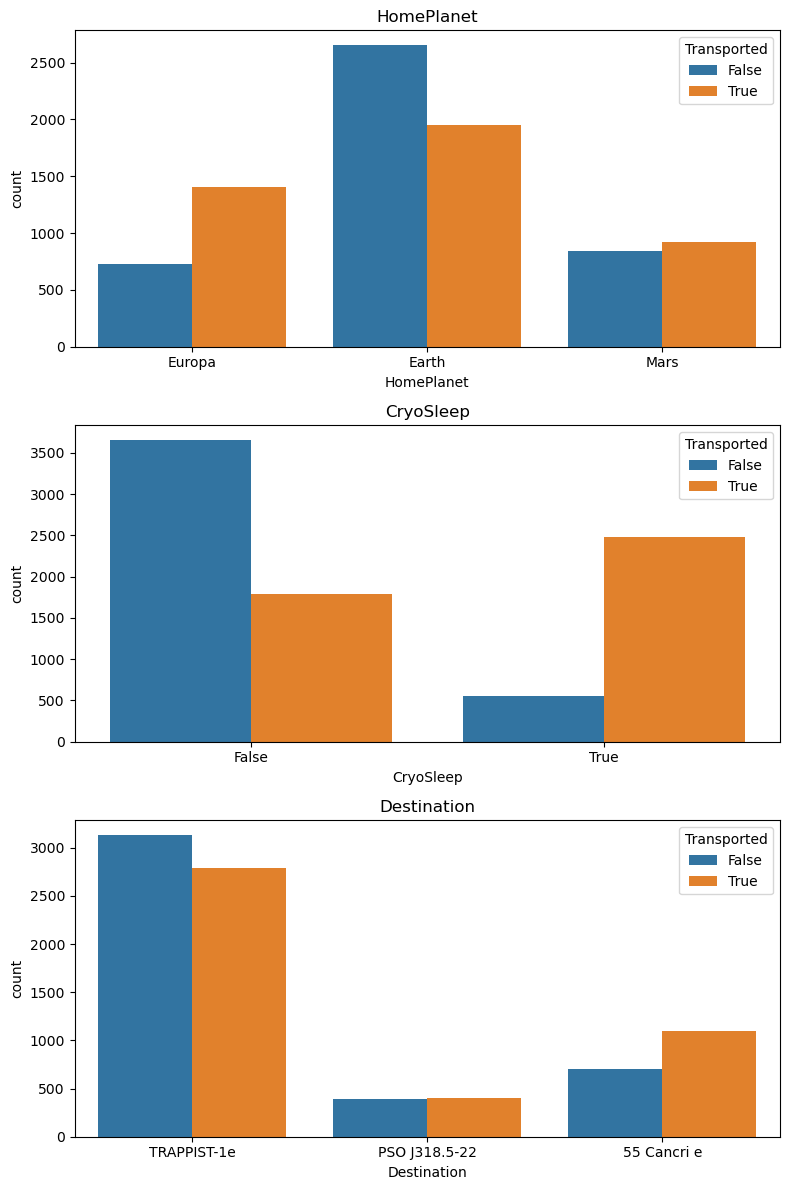

In [80]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))  # 크기 키우기

sns.countplot(data=train_df, x='HomePlanet', hue='Transported', ax=axes[0])
axes[0].set_title('HomePlanet')

sns.countplot(data=train_df, x='CryoSleep', hue='Transported', ax=axes[1])
axes[1].set_title('CryoSleep')

sns.countplot(data=train_df, x='Destination', hue='Transported', ax=axes[2])
axes[2].set_title('Destination')

plt.tight_layout()  # 🔥 이거 핵심
plt.show()

#### 그래프를 통한 추측
 - 고향행성에 따라서
    - 유로파 : 전송 > 이송
    - 지구 : 전송 < 이송
    - 화성 : 전송 < 이송
 - 극저온수면 여부에 따라서
    - 극저온수면 하였음 : 전송 > 이송
    - 극저온수면 하지않음 : 전송 < 이송
 - 목적지에 따라서
    - TRAPPIST-1e : 전송 < 이송
    - PSO J318.5-22 : 전송 = 이송 
    - 55 cancri e : 전송 > 이송

## 3. 누락된 값 제어하기

In [81]:
Missing_features = ['FoodCourt','Spa','ShoppingMall','RoomService','VRDeck','Cabin','CryoSleep','VIP','HomePlanet','Destination','Age']
for feature in Missing_features:
    if feature=='Age':
        fill = train_df[feature].mean() # 나이의 경우, 평균값을 집어넣음
    else:
        fill = train_df[feature].value_counts().index[0]
    train_df[feature] = train_df[feature].fillna(fill)
    test_df[feature] = test_df[feature].fillna(fill)

/tmp/ipykernel_128/2335602519.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[feature] = train_df[feature].fillna(fill)
/tmp/ipykernel_128/2335602519.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df[feature] = test_df[feature].fillna(fill)
/tmp/ipykernel_128/2335602519.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tru

#### 데이터 내 결측치는 분석 및 모델 학습 과정에서 오류를 발생시키거나 결과를 왜곡시킬 수 있기 때문에 적절한 제어가 필요하다.
#### 특히 결측치를 그대로 사용할 경우 모델의 학습 성능이 저하될 수 있어, 데이터 특성에 맞는 방식으로 처리하는 것이 중요하다.
#### 본 데이터에서는 결측치 비율이 낮고 랜덤하게 분포되어 있어,
#### 데이터 손실을 최소화하기 위해 제거가 아닌 제어 방식을 사용하게 되었습니다.
#### 위에 빨간색은 오류코드가 아닌 경고로 무시해도 괜찮다고 해서 그냥 넣게 되었습니다. 해결하려면 시간이 부족할거같아서 나중에 해결해보겠습니다.

## 4. 좌석 분리 및 분석
#### 0.에있는 Spaceship Titanic: A complete guide 자료 참조

In [82]:
def extract_deck(s):
    return s.split('/')[0] # 갑판의 경우, 슬래쉬 앞부분의 자료

def extract_num(s):
    return s.split('/')[1] # 좌석의 경우, 슬래쉬 중간부분의 자료

def extract_side(s):
    return s.split('/')[2] # 방향의 경우, 슬래쉬 오른쪽 부분의 자료

train_df['Deck'] = train_df['Cabin'].apply(extract_deck)
train_df['Num'] = train_df['Cabin'].apply(extract_num)
train_df['Side'] = train_df['Cabin'].apply(extract_side)

test_df['Deck'] = test_df['Cabin'].apply(extract_deck)
test_df['Num'] = test_df['Cabin'].apply(extract_num)
test_df['Side'] = test_df['Cabin'].apply(extract_side)

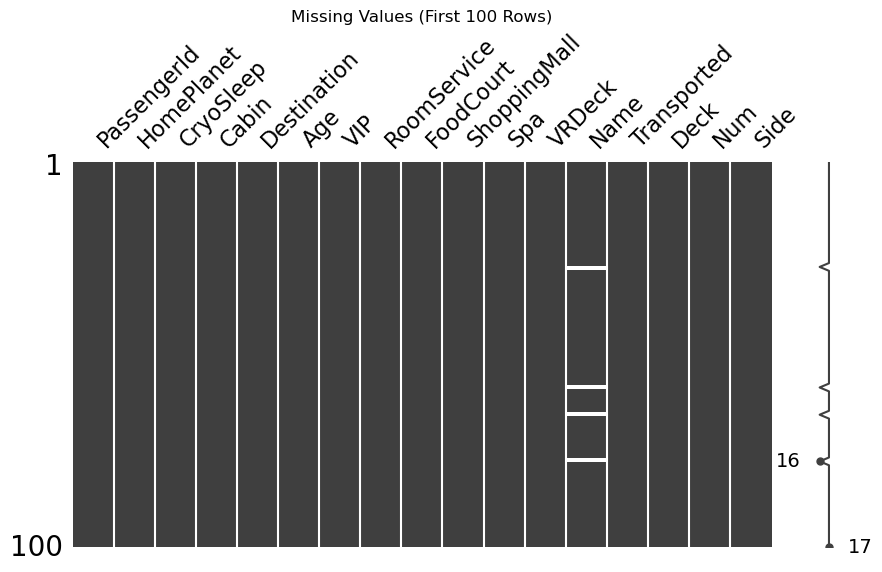

In [83]:
msno.matrix(train_df.iloc[:100], figsize=(10,5))
plt.title('Missing Values (First 100 Rows)')
plt.show()

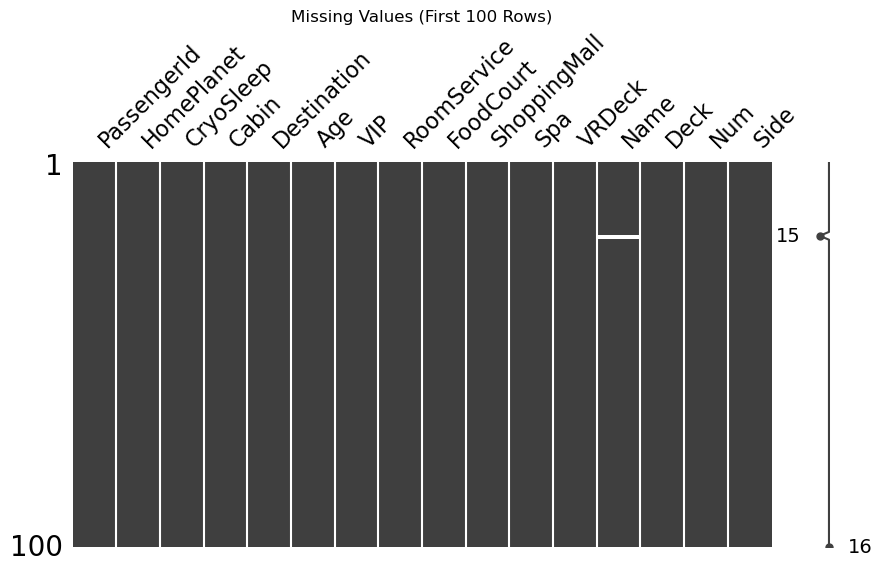

In [84]:
msno.matrix(test_df.iloc[:100], figsize=(10,5))
plt.title('Missing Values (First 100 Rows)')
plt.show()

## 5. 카테고리형 데이터를 수치적 데이터로 변환하기

In [85]:
features_cat = ['HomePlanet', 'Destination', 'Deck', 'Side'] # 카테고리형 데이터 칼럼 묶음의 설정
for feature in features_cat:
    train_df[pd.get_dummies(train_df[feature], prefix=feature).columns] = pd.get_dummies(train_df[feature], prefix=feature)
    test_df[pd.get_dummies(test_df[feature], prefix=feature).columns] = pd.get_dummies(test_df[feature], prefix=feature) #합쳐서 작업

In [86]:
data = pd.concat([train_df[test_df.columns], test_df])
data

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00000,False,0.0,0.0,0.0,...,False,True,False,False,False,False,False,False,True,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00000,False,109.0,9.0,25.0,...,False,False,False,False,False,True,False,False,False,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00000,True,43.0,3576.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00000,False,0.0,1283.0,371.0,...,True,False,False,False,False,False,False,False,False,True
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00000,False,303.0,70.0,151.0,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.00000,False,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,True
4273,9269_01,Earth,False,G/734/S,TRAPPIST-1e,42.00000,False,0.0,847.0,17.0,...,False,False,False,False,False,False,True,False,False,True
4274,9271_01,Mars,True,D/296/P,55 Cancri e,28.82793,False,0.0,0.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4275,9273_01,Europa,False,D/297/P,TRAPPIST-1e,28.82793,False,0.0,2680.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PassengerId                12970 non-null  object 
 1   HomePlanet                 12970 non-null  object 
 2   CryoSleep                  12970 non-null  bool   
 3   Cabin                      12970 non-null  object 
 4   Destination                12970 non-null  object 
 5   Age                        12970 non-null  float64
 6   VIP                        12970 non-null  bool   
 7   RoomService                12970 non-null  float64
 8   FoodCourt                  12970 non-null  float64
 9   ShoppingMall               12970 non-null  float64
 10  Spa                        12970 non-null  float64
 11  VRDeck                     12970 non-null  float64
 12  Name                       12676 non-null  object 
 13  Deck                       12970 non-null  object 
 

## 6. 이름 관련 데이터 제어

#### 승객의 Name 변수에서 성(last name)을 기준으로 동일한 이름을 가진 승객 여부를 나타내는 SameName 변수를 생성하였다.
- 이는 가족 또는 그룹 단위로 이동하는 승객의 특성을 반영하기 위함이다.
- 동일한 성을 가진 승객들은 유사한 행동 패턴을 보일 가능성이 높으며,
- 이에 따라 전송/이송 여부에도 영향을 미칠 수 있다고 판단하였다.
- name의 빈데이터는 이제 무시해도 될거같다

In [88]:
def extract_last_name(s): # extract_last_name(성씨 추출)이라는 함수?의 정의
    return str(s).split(' ')[-1] #참조에서 끌어온 거라 해당 부분의 -1 이 의미하는 바를 아직도 확인하지 못하였음. 확인 들어갈 예정

data['LastName'] = data['Name'].apply(extract_last_name) # data 에 성씨 추출을 적용

dict_names = data['LastName'].value_counts().to_dict()

def same_name(s): #같은이름이라는 명령어? 함수의 정의
    return dict_names[s]-1

data['SameName'] = data['LastName'].apply(same_name)

In [89]:
to_train = data.iloc[0:8693]
train_df['SameName'] = pd.Series(to_train['SameName'])

In [90]:
to_test = data.iloc[8693:]
test_df['SameName'] = pd.Series(to_test['SameName'])

<Axes: >

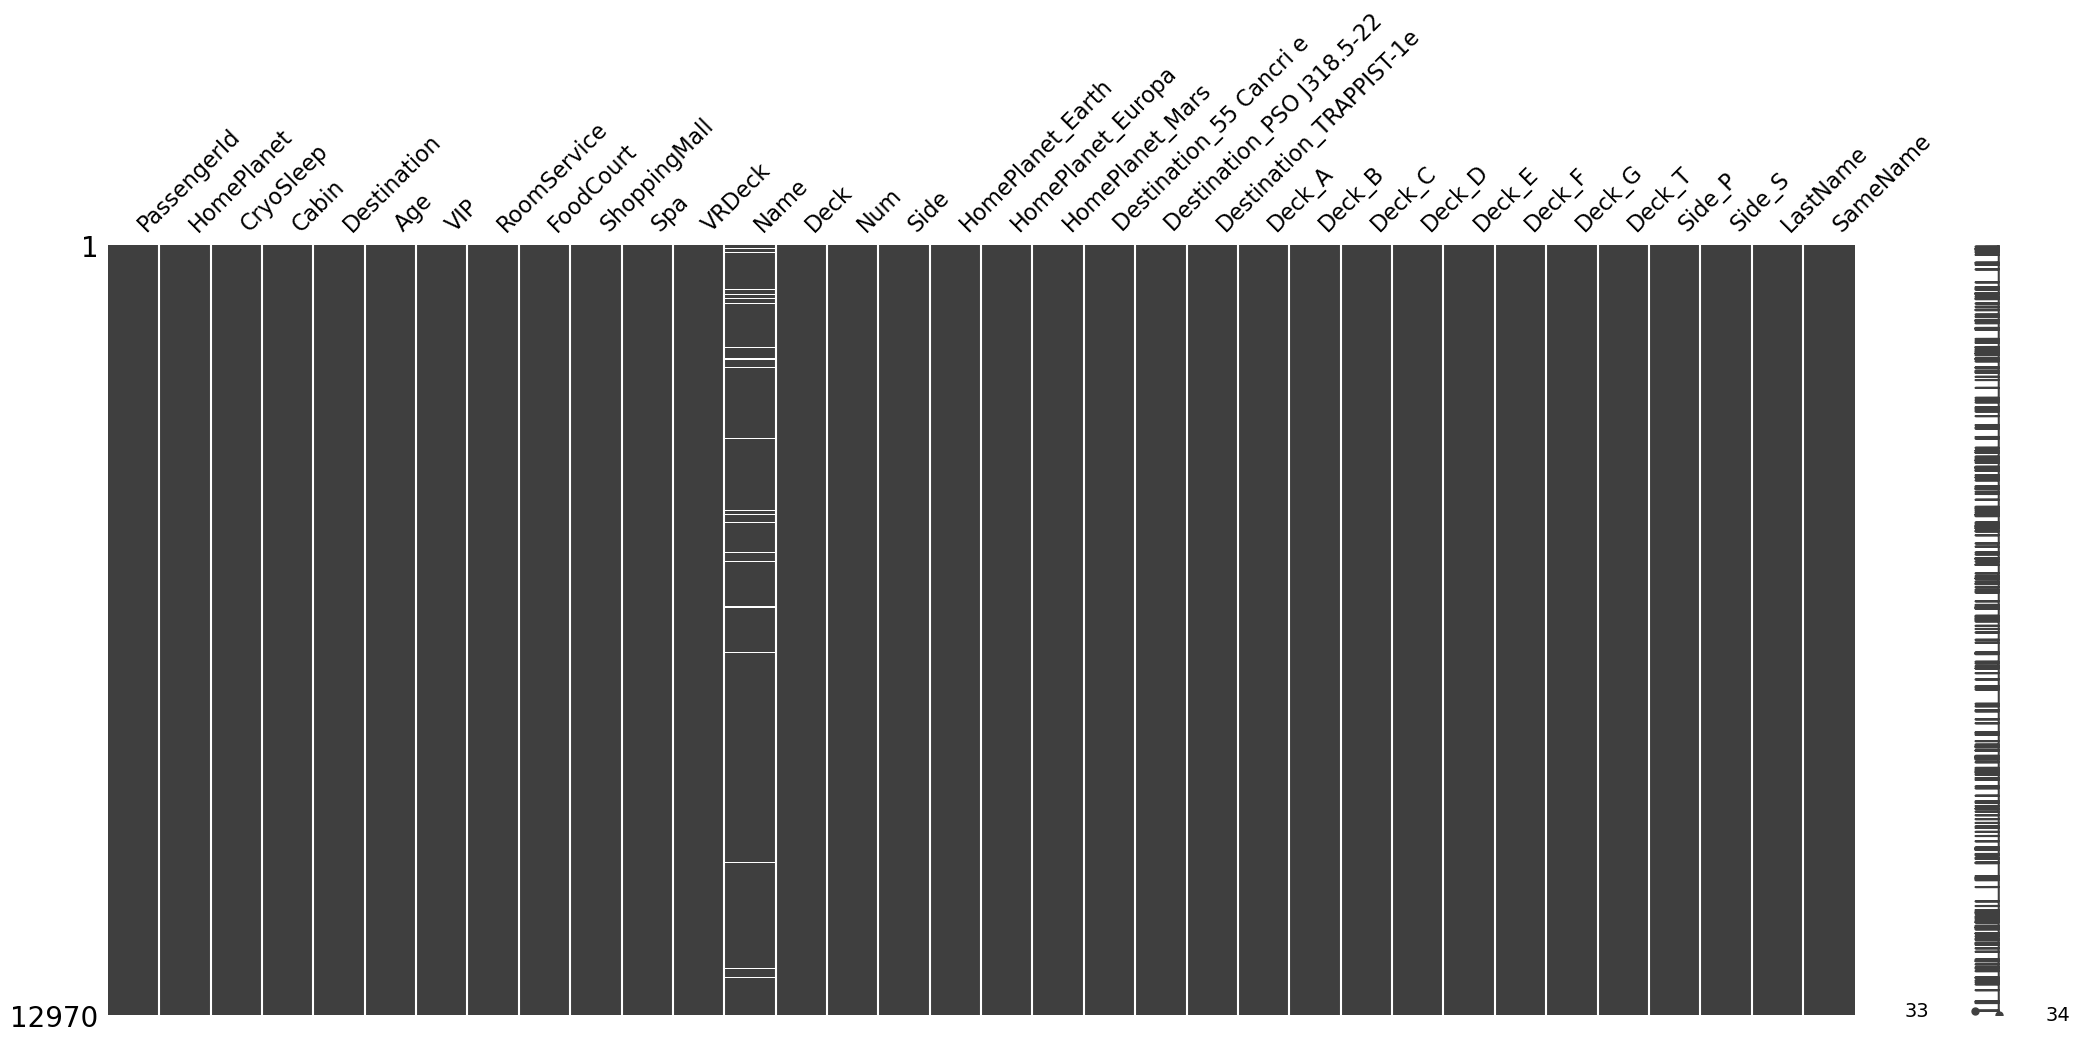

In [91]:
missingno.matrix(data)

## 7. 나이 관련 데이터 제어
- 10세 간격으로 끊어서 나이별로 그룹을 정리함

In [92]:
def age_group(s):
    if s == 0:
        return -1
    elif (s >= 0) & (s < 10):
        return 1
    elif (s >= 10) & (s < 20):
        return 2
    elif (s >= 20) & (s < 30):
        return 3
    elif (s >= 30) & (s < 40):
        return 4
    elif (s >= 40) & (s < 50):
        return 5
    elif (s >= 50) & (s < 60):
        return 6
    elif (s >= 60) & (s < 70):
        return 7
    elif (s >= 70) & (s < 80):
        return 8
    
train_df['Age_Group'] = train_df['Age'].apply(age_group)
test_df['Age_Group'] = test_df['Age'].apply(age_group)

## 8. 필요없는 칼럼을 정리
- 탑승객ID는 탑승객들의 매우 고유한 데이터이나, 모델을 만들기 쉽지 않음.
- 카테고리형 데이터는 모두 나누었으므로, 원본 카테고리 칼럼은 지우면 됨
- 나이와 이름, 목적지, 선실까지 분석하였으므로, 더이상 원본 칼럼은 필요없음

In [93]:
train_df.drop(['PassengerId','HomePlanet','Cabin','Destination','Name','Age','Deck','Side'], axis = 1, inplace = True)

In [94]:
test_df.drop(['PassengerId','HomePlanet','Cabin','Destination','Name','Age','Deck','Side'], axis = 1, inplace = True)

## 9. 아까 합쳤던 데이터를 쪼개기
- 이제 변수로 지정해줘서 아래에 테스팅 결과값에 집어넣을 예정

In [110]:
from sklearn.model_selection import train_test_split

X = train_df.drop(['Transported'], axis=1)
y = train_df['Transported']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 10. 정확도 테스팅
- 1차시도 기본적인 모델로 시도해봤는데 0.792퍼가 나옴
- 2차시도 XGBClassifier를 사용해봤는데 0.81퍼가 나옴 이렇게 잘되니 갑자기 기분이 좋아짐 ai의 도움을 받긴 하였습니다. 위에글도 참고해보고 다른글도 참고해봤습니다.

In [114]:
param_grid = {'n_estimators': [10, 30, 50, 70, 90],
              'learning_rate': [0.4, 0.2, 0.2, 0.1],
              'eval_metric': ['mlogloss']}
grid = GridSearchCV(XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
best_params_1 = grid.best_params_
print('Best score of cross validation: {:.2f}'.format(grid.best_score_))
print('Best parameters_1:', best_params_1)

Best score of cross validation: 0.81
Best parameters_1: {'eval_metric': 'mlogloss', 'learning_rate': 0.2, 'n_estimators': 30}


- 모델의 성능을 최적화하기 위해 GridSearchCV를 활용하여 하이퍼파라미터 튜닝을 수행하였다.
- n_estimators와 learning_rate 등의 파라미터를 다양한 조합으로 설정하고,
- 5-fold 교차 검증을 통해 가장 높은 정확도를 보이는 최적의 파라미터를 탐색하였다.

- 그 결과, 최적의 파라미터 조합과 함께 향상된 모델 성능을 확인할 수 있었다.

## 11. 케글에 제출 하기위한 과정
- 모델 데이터를 학습 시키고 예측값을 넣습니다.
- 125번 코드를 사용해 submission을 생성하여
- 그아래 코드로 제대로 출력이 되는지 한번더 재검사를 합니다
- 마지막 코드를 사용해 저장을 해줍니다.
- 케글에 제출하였는데 케글스코어 0.80056이 나왔습니다. 

In [119]:
model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
y_pred = model.predict(X_val)

In [121]:
test_pred = model.predict(test_df)

In [125]:
submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Transported': test_pred
})

In [126]:
print(submission.head())

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


In [127]:
submission.to_csv('submission.csv', index=False)